# SARSA (State-Action-Reward-State-Action)

SARSA is an **on-policy** Temporal Difference control algorithm. "On-policy" means it learns
the value of the policy it is actually following (including its exploration steps), unlike
Q-Learning which is off-policy.

### Update Equation

Q(s,a) <- Q(s,a) + α [ R + γ Q(s',a') - Q(s,a) ]

Notice that the next action `a'` used in the update is the action that the agent **actually
takes** next (chosen by the epsilon-greedy policy), not the greedy max action.

We use the `CliffWalking-v1` environment from `gymnasium`, where the agent must walk from a
start cell to a goal cell on a 4x12 grid without falling off a cliff (which gives -100 reward).


In [1]:
!pip install -q "gymnasium[toy-text]"

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt


In [3]:
# Sample env
env = gym.make("CliffWalking-v1")

print(env.observation_space.n)  # states
print(env.action_space.n)       # actions

starting_state, _ = env.reset()
print(starting_state)


48
4
36


## SARSA

In [4]:
gamma = 0.99
alpha = 0.5
epsilon = 0.1
episodes = 500


In [5]:
# Q-table => store Q-values
Q = np.zeros((48, 4))


In [6]:
# Policy - epsilon-greedy : state -> action

def epsilon_greedy(state):
    if random.random() < epsilon:
        return env.action_space.sample()  # random action => EXPLORE
    else:
        return np.argmax(Q[state])        # exploit


In [7]:
rewards_per_episode = []

for episode in range(episodes):

    state, _ = env.reset()
    action = epsilon_greedy(state)

    done = False
    total_reward = 0

    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        next_action = epsilon_greedy(next_state)

        # SARSA update - uses the action actually taken next
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * Q[next_state, next_action] - Q[state, action]
        )

        state = next_state
        action = next_action
        total_reward += reward

    rewards_per_episode.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode+1}/{episodes} - Total Reward: {total_reward}")

print("Training Completed!")


Episode 100/500 - Total Reward: -28
Episode 200/500 - Total Reward: -20
Episode 300/500 - Total Reward: -20
Episode 400/500 - Total Reward: -122
Episode 500/500 - Total Reward: -33
Training Completed!


## Reward Plot

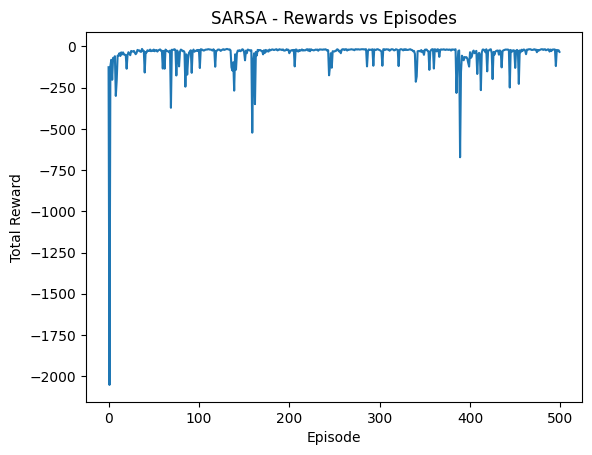

In [8]:
plt.plot(rewards_per_episode)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("SARSA - Rewards vs Episodes")
plt.show()


## Final Policy

In [9]:
policy = np.argmax(Q, axis=1)

# CliffWalking is a 4x12 grid
print("Learned Policy (4x12 grid):")
print(policy.reshape(4, 12))

# 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT


Learned Policy (4x12 grid):
[[1 1 1 1 1 1 1 1 1 1 1 2]
 [0 0 0 1 0 0 0 1 0 1 0 2]
 [0 3 1 1 0 0 0 0 3 0 1 2]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


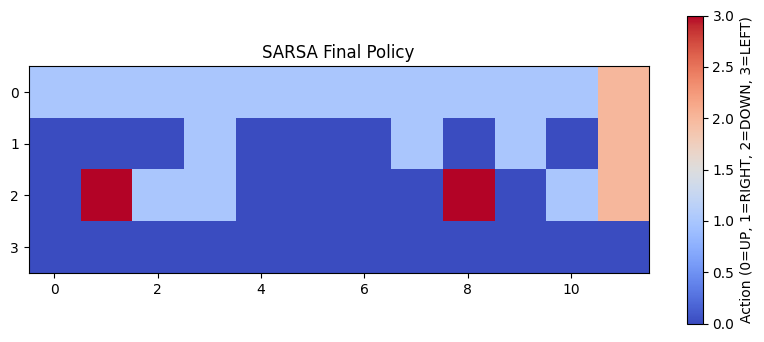

In [10]:
plt.figure(figsize=(10, 4))
plt.imshow(policy.reshape(4, 12), cmap="coolwarm")
plt.colorbar(label="Action (0=UP, 1=RIGHT, 2=DOWN, 3=LEFT)")
plt.title("SARSA Final Policy")
plt.show()


## Conclusion

Because SARSA is on-policy, it accounts for the risk of exploration during learning - it
tends to learn a **safer path** that stays away from the cliff, since occasionally taking
random exploratory actions near the cliff edge would be costly. This is different from
Q-Learning, which learns the optimal (riskier, shorter) path along the cliff edge because it
always bootstraps off the greedy action.
